In [4]:
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

Линеаризуем систему и посчитаем точки равновесия с помощью sympy, а затем просимулируем линеаризованную систему с помощью scipy.

In [ ]:
x, y = sp.symbols('x y')
vx, vy = sp.symbols('vx vy')
m, g = sp.symbols('m g')
k1, k2, k3 = sp.symbols('k1 k2 k3')
L01, L02, L03 = sp.symbols('L01 L02 L03')
mu = sp.symbols('mu')
L_wall, L_floor, L_tilt = sp.symbols('L_wall L_floor L_tilt')

x1, y1 = 0, L_wall
x2, y2 = L_floor, 0
x3, y3 = L_tilt * sp.sin(mu), L_tilt * sp.cos(mu)

dist1 = sp.sqrt((x - x1)**2 + (y - y1)**2)
dist2 = sp.sqrt((x - x2)**2 + (y - y2)**2)
dist3 = sp.sqrt((x - x3)**2 + (y - y3)**2)

V = (k1/2 * (dist1 - L01)**2 +
     k2/2 * (dist2 - L02)**2 +
     k3/2 * (dist3 - L03)**2 +
     m * g * y)

Fx = -sp.diff(V, x)
Fy = -sp.diff(V, y)

params = {
    m: 1.0, g: 9.81,
    k1: 50.0, k2: 50.0, k3: 50.0,
    L01: 0.5, L02: 0.5, L03: 0.5,
    mu: np.radians(80),
    L_wall: 1.0,
    L_floor: 1.0,
    L_tilt: 1.2
}

eq_point = sp.nsolve([Fx.subs(params), Fy.subs(params)], [x, y], [0.5, 0.5])
x0, y0 = float(eq_point[0]), float(eq_point[1])

J = sp.Matrix([[sp.diff(Fx, x), sp.diff(Fx, y)],
               [sp.diff(Fy, x), sp.diff(Fy, y)]])

A_sub = np.array(J.subs({x: x0, y: y0, **params})).astype(np.float64) / params[m]

# Построение матрицы состояния A (4x4) для z = [dx, dvx, dy, dvy] из матрицы линеаризации
A = np.zeros((4, 4))
A[0, 1], A[2, 3] = 1, 1
A[1, 0], A[1, 2] = A_sub[0, 0], A_sub[0, 1]
A[3, 0], A[3, 2] = A_sub[1, 0], A_sub[1, 1]

# СИМУЛЯЦИЯ
def system_ode(t, z):
    return A @ z

# Начальное отклонение
z0 = [0.03, 0, 0.01, 0]
t_span = (0, 10)
t_eval = np.linspace(0, 10, 1000)

sol = solve_ivp(system_ode, t_span, z0, t_eval=t_eval)

dx, dvx, dy, dvy = sol.y

x_abs = x0 + dx
y_abs = y0 + dy

anchor1 = np.array([0.0, float(L_wall.subs(params))])
anchor2 = np.array([float(L_floor.subs(params)), 0.0])
anchor3 = np.array([float((L_tilt * sp.sin(mu)).subs(params)),
                    float((L_tilt * sp.cos(mu)).subs(params))])
E_kin = 0.5 * params[m] * (dvx**2 + dvy**2)

dist1_act = np.sqrt((x_abs - anchor1[0])**2 + (y_abs - anchor1[1])**2)
dist2_act = np.sqrt((x_abs - anchor2[0])**2 + (y_abs - anchor2[1])**2)
dist3_act = np.sqrt((x_abs - anchor3[0])**2 + (y_abs - anchor3[1])**2)

E_springs = (0.5 * params[k1] * (dist1_act - params[L01])**2 +
             0.5 * params[k2] * (dist2_act - params[L02])**2 +
             0.5 * params[k3] * (dist3_act - params[L03])**2)

E_grav = params[m] * params[g] * y_abs

E_pot = E_springs + E_grav
E_total = E_kin + E_pot

Изобаразим графики энергии и траектоории.

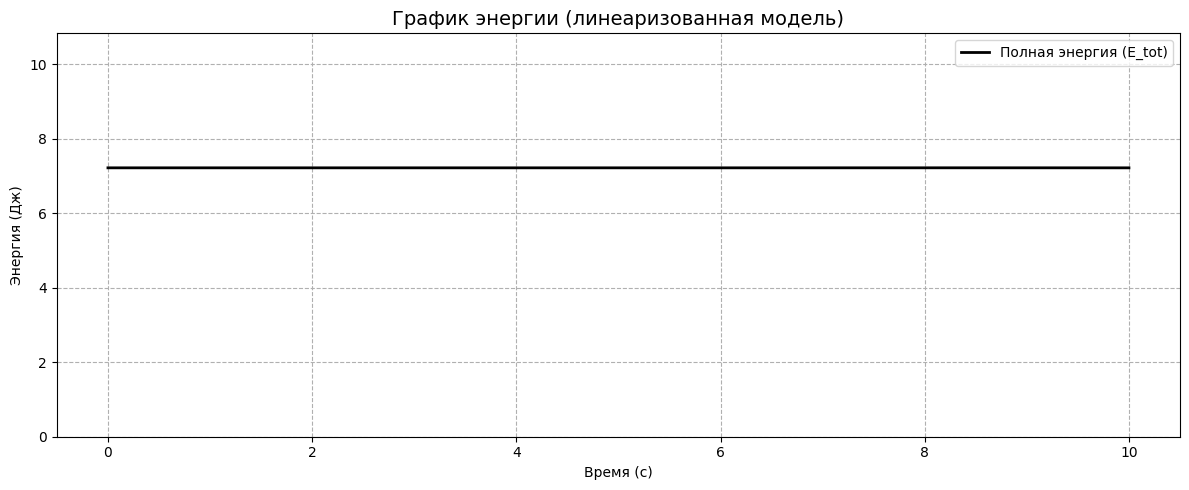

In [14]:
plt.figure(figsize=(12,5))


plt.plot(sol.t, E_total, color='black', lw=2, label='Полная энергия (E_tot)')
plt.title("График энергии (линеаризованная модель)", fontsize=14)
plt.xlabel("Время (с)")
plt.ylabel("Энергия (Дж)")
plt.ylim(0, max(E_total) * 1.5)
plt.grid(True, linestyle='--')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

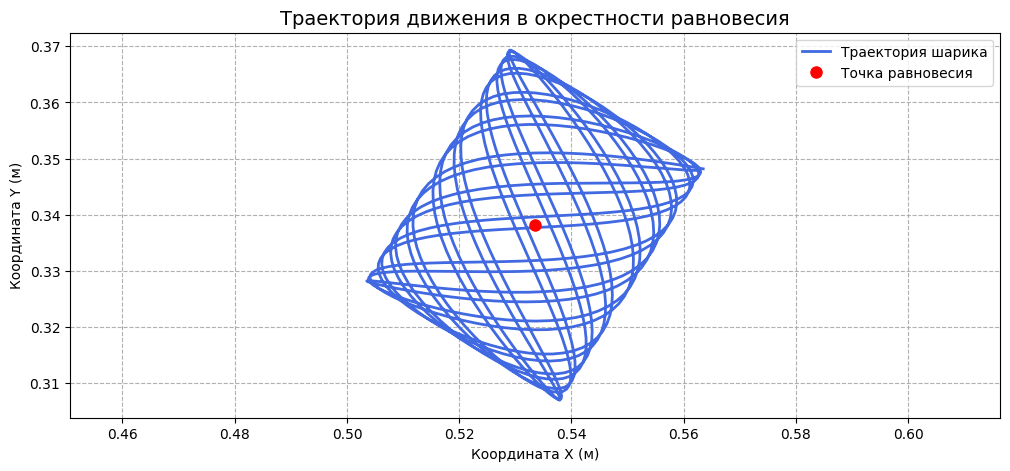

In [15]:
plt.figure(figsize= (12,5))

plt.plot(x0 + dx, y0 + dy, color='royalblue', lw=2, label='Траектория шарика')
plt.plot(x0, y0, 'ro', markersize=8, label='Точка равновесия')

plt.title("Траектория движения в окрестности равновесия", fontsize=14)
plt.xlabel("Координата X (м)")
plt.ylabel("Координата Y (м)")
plt.axis('equal')
plt.grid(True, linestyle='--')
plt.legend()

plt.show()